In [4]:
!pip install jedi

In [ ]:
# Auto-download sample PDF files from the repo
import os
if not os.path.exists("sample_contract.pdf"):
    !wget -q https://raw.githubusercontent.com/prijal21/RAG_PipeLine/main/sample_contract.pdf
    !wget -q https://raw.githubusercontent.com/prijal21/RAG_PipeLine/main/sample_contract_1.pdf
    !wget -q https://raw.githubusercontent.com/prijal21/RAG_PipeLine/main/sample_contract_2.pdf
    print("Sample files downloaded.")
else:
    print("Sample files already present.")


In [10]:
import os
import fitz  # PyMuPDF
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import nest_asyncio

nest_asyncio.apply()

# Set up Google API key for Gemini
from google.colab import userdata
GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

# Create a directory for our PDFs if it doesn't exist
!mkdir -p sample_docs

In [11]:
from google.colab import files
import os

def upload_pdf():
    """Upload a PDF file and return its path."""
    print("Please select a PDF file to upload:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        if filename.endswith('.pdf'):
            # Save to the sample_docs directory
            pdf_path = os.path.join("sample_docs", filename)

            # Create directory if it doesn't exist
            os.makedirs("sample_docs", exist_ok=True)

            # Save the file
            with open(pdf_path, 'wb') as f:
                f.write(uploaded[filename])

            print(f"PDF saved to {pdf_path}")
            return pdf_path
        else:
            print(f"File {filename} is not a PDF. Please upload a PDF file.")

    return None



In [12]:
 # Upload your own PDF
pdf_path = upload_pdf()

Please select a PDF file to upload:


Saving sample_contract.pdf to sample_contract (2).pdf
PDF saved to sample_docs/sample_contract (2).pdf


In [13]:
pdf_path = "/content/sample_docs/sample_contract.pdf"

In [14]:
def extract_text_from_pdf(pdf_path):
    """Extract text from a PDF file using PyMuPDF."""
    doc = fitz.open(pdf_path)

    # Extract text from all pages
    text = "\n".join([page.get_text() for page in doc])

    # Print some stats
    print(f"PDF: {pdf_path}")
    print(f"Number of pages: {len(doc)}")
    print(f"Extracted {len(text.split())} words from the PDF.")

    # Close the document
    doc.close()

    return text


In [15]:
# Example usage (after uploading a PDF):
if pdf_path:
    text = extract_text_from_pdf(pdf_path)
    print(text[:500])  # Print first 500 character

PDF: /content/sample_docs/sample_contract.pdf
Number of pages: 2
Extracted 315 words from the PDF.
SERVICE AGREEMENT CONTRACT
This Service Agreement (the "Agreement") is entered into as of January 15, 2025 (the "Effective Date")
by and between:
ABC Company Inc., with its principal place of business at 123 Business Avenue, Corporate City, State
12345 ("Service Provider"); and
XYZ Corporation, with its principal place of business at 456 Commerce Street, Enterprise Town, State
67890 ("Client").
1. SERVICES
1.1 Service Provider agrees to provide Client with consulting services ("Services") as des


In [16]:
from llama_index.core import Document
from typing import List

def load_pdf_with_pymupdf(pdf_path: str) -> List[Document]:
    """Load a PDF and convert it to LlamaIndex Document format using PyMuPDF."""
    # Open the PDF
    doc = fitz.open(pdf_path)

    # Extract text from each page
    documents = []

    for i, page in enumerate(doc):
        text = page.get_text()

        # Skip empty pages
        if not text.strip():
            continue

        # Create Document object with metadata
        documents.append(
            Document(
                text=text,
                metadata={
                    "file_name": os.path.basename(pdf_path),
                    "page_number": i + 1,
                    "total_pages": len(doc)
                }
            )
        )

    # Close the document
    doc.close()

    # Print stats
    print(f"Processed {pdf_path}:")
    print(f"Extracted {len(documents)} pages with content")

    return documents


In [17]:
# Example usage:
pdf_docs = load_pdf_with_pymupdf(pdf_path)

Processed /content/sample_docs/sample_contract.pdf:
Extracted 2 pages with content


In [18]:
!pip install llama-index-core llama-index-llms-google-genai llama-index-embeddings-huggingface

In [19]:
from llama_index.llms.google_genai import GoogleGenAI
from llama_index.core import Settings
from llama_index.core import VectorStoreIndex
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize Gemini LLM
llm = GoogleGenAI(model="gemini-2.0-flash")
Settings.llm = llm

# Initialize embedding model
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
Settings.embed_model = embed_model

def process_and_index_pdf(pdf_path):
    """Process a PDF and create both vector and keyword indices."""
    # Load documents
    documents = load_pdf_with_pymupdf(pdf_path)

    # Create vector index
    vector_index = VectorStoreIndex.from_documents(documents)

    print(f"Indexed {len(documents)} document chunks")

    return vector_index

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
# Step 2: Index the PDF
index = process_and_index_pdf(pdf_path)

Processed /content/sample_docs/sample_contract.pdf:
Extracted 2 pages with content
Indexed 2 document chunks


In [21]:
from llama_index.llms.google_genai import GoogleGenAI
from llama_index.core import Settings

# Initialize Gemini LLM
llm = GoogleGenAI(model="gemini-2.0-flash")
Settings.llm = llm

# Simple query expansion function using Gemini
def expand_query(query: str, num_expansions: int = 3) -> list:
    """Expand a query to include related terms using Gemini."""
    prompt = f"""
    I need to search a legal contract with this query: "{query}"

    Please help me expand this query by generating {num_expansions} alternative versions that:
    1. Use different but related terminology
    2. Include relevant legal terms that might appear in a contract
    3. Cover similar concepts but phrased differently

    Format your response as a list of alternative queries only, with no additional text.
    """

    response = llm.complete(prompt)

    # Extract the expanded queries
    expanded_queries = [line.strip() for line in response.text.split('\n') if line.strip()]

    # Add the original query if needed
    if query not in expanded_queries:
        expanded_queries = [query] + expanded_queries

    return expanded_queries

In [22]:
# Example usage:
expanded = expand_query("What are the penalties for late payments?")
for i, q in enumerate(expanded):
    print(f"{i+1}. {q}")

1. What are the penalties for late payments?
2. *   "What are the consequences of payment default or delinquency?"
3. *   "What remedies are available for non-payment or delayed payment, including interest or liquidated damages?"
4. *   "Under what circumstances are late fees or other charges assessed for payments not received by the due date, and what is the calculation method?"


In [23]:
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.retrievers import QueryFusionRetriever

# Function to create a query engine that uses query expansion
def create_query_expansion_engine(index):
    """Create a query engine that uses query expansion."""
    # First create multiple retrievers (base retriever)
    base_retriever = index.as_retriever(similarity_top_k=2)

    # Create a query fusion retriever
    fusion_retriever = QueryFusionRetriever(
        retrievers=[base_retriever],
        llm=llm,
        similarity_top_k=2,
        num_queries=3,  # Generate 3 queries per original query
        mode="reciprocal_rerank"  # Use reciprocal rank fusion
    )

    # Create the query engine with the fusion retriever
    query_engine = RetrieverQueryEngine.from_args(
        retriever=fusion_retriever,
        llm=llm,
        verbose=True
    )

    return query_engine

In [25]:
# Example usage:
expanded_query_engine = create_query_expansion_engine(index)
response = expanded_query_engine.query("What are the penalties for late payments?")
print(response)

Late payments will be charged interest at a rate of 1.5% per month from the due date until the balance is paid in full.



In [26]:
!pip install llama-index-retrievers-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 39.5 MB/s eta 0:00:00


In [27]:
from llama_index.core import VectorStoreIndex
from llama_index.retrievers.bm25 import BM25Retriever

def create_hybrid_retriever(index, query, top_k=2):
    """Create a hybrid retrieval approach combining vector and keyword search."""
    # Method 1: Vector retrieval (semantic search)
    vector_retriever = index.as_retriever(similarity_top_k=top_k)
    vector_nodes = vector_retriever.retrieve(query)

    # Method 2: BM25 retrieval (keyword-based search)
    # Get all nodes from the index
    nodes = [node for node in index.docstore.docs.values()]
    bm25_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=top_k
    )
    keyword_nodes = bm25_retriever.retrieve(query)

    # Combine results (simple approach)
    all_nodes = []
    all_nodes.extend(vector_nodes)
    all_nodes.extend(keyword_nodes)

    # Remove duplicates
    unique_nodes = []
    seen_ids = set()
    for node in all_nodes:
        if node.node_id not in seen_ids:
            unique_nodes.append(node)
            seen_ids.add(node.node_id)

    # Sort by score (higher is better)
    sorted_nodes = sorted(unique_nodes, key=lambda x: x.score if hasattr(x, 'score') else 0.0, reverse=True)

    # Limit to top results
    top_nodes = sorted_nodes[:top_k]

    return top_nodes

In [28]:
# Example usage:
hybrid_nodes = create_hybrid_retriever(index, "What is the refund policy?")
for i, node in enumerate(hybrid_nodes):
    print(f"Result {i+1} (Score: {node.score:.4f}):")
    print(node.get_text())
    print("-" * 40)

DEBUG:bm25s:Building index from IDs objects


Result 1 (Score: 0.3964):
4.3 No refunds will be issued for completed projects that meet the specifications outlined in Exhibit A.
5. CONFIDENTIALITY
5.1 Each party acknowledges that it may receive confidential information from the other party during the
performance of this Agreement.
5.2 Each party agrees to maintain the confidentiality of such information and not to disclose it to any
third party without prior written consent.
----------------------------------------
Result 2 (Score: 0.2210):
SERVICE AGREEMENT CONTRACT
This Service Agreement (the "Agreement") is entered into as of January 15, 2025 (the "Effective Date")
by and between:
ABC Company Inc., with its principal place of business at 123 Business Avenue, Corporate City, State
12345 ("Service Provider"); and
XYZ Corporation, with its principal place of business at 456 Commerce Street, Enterprise Town, State
67890 ("Client").
1. SERVICES
1.1 Service Provider agrees to provide Client with consulting services ("Services") as des

In [29]:
def compare_retrieval_methods(index, query, top_k=2):
    """Compare different retrieval methods for the same query."""
    # Vector retrieval
    vector_retriever = index.as_retriever(similarity_top_k=top_k)
    vector_nodes = vector_retriever.retrieve(query)

    # Keyword retrieval (BM25)
    nodes = [node for node in index.docstore.docs.values()]
    keyword_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=top_k
    )
    keyword_nodes = keyword_retriever.retrieve(query)

    # Hybrid retrieval
    hybrid_nodes = create_hybrid_retriever(index, query, top_k)

    # Create a comparison dataframe
    results = []

    for method, nodes in [
        ("Vector (Semantic)", vector_nodes),
        ("Keyword (BM25)", keyword_nodes),
        ("Hybrid", hybrid_nodes)
    ]:
        for i, node in enumerate(nodes):
            results.append({
                "Method": method,
                "Rank": i + 1,
                "Score": node.score if hasattr(node, 'score') else 0.0,
                "Content": node.get_text()[:200] + "...",  # First 200 chars
                "Page": node.metadata.get("page_number", "Unknown") if hasattr(node, 'metadata') else "Unknown"
            })

    results_df = pd.DataFrame(results)
    display(results_df)

    # Visualize scores
    plt.figure(figsize=(10, 6))
    for method in ["Vector (Semantic)", "Keyword (BM25)", "Hybrid"]:
        method_df = results_df[results_df["Method"] == method]
        plt.bar(
            [f"{method} - Rank {row['Rank']}" for _, row in method_df.iterrows()],
            method_df["Score"],
            alpha=0.7,
            label=method
        )

    plt.xlabel("Result")
    plt.ylabel("Retrieval Score")
    plt.title(f"Comparison of Retrieval Methods for Query: '{query}'")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df

DEBUG:bm25s:Building index from IDs objects
DEBUG:bm25s:Building index from IDs objects


,Method,Rank,Score,Content,Page
0,Vector (Semantic),1,0.396365,4.3 No refunds will be issued for completed pr...,2
1,Vector (Semantic),2,0.221004,SERVICE AGREEMENT CONTRACT\nThis Service Agree...,1
2,Keyword (BM25),1,0.322329,SERVICE AGREEMENT CONTRACT\nThis Service Agree...,1
3,Keyword (BM25),2,0.100949,4.3 No refunds will be issued for completed pr...,2
4,Hybrid,1,0.396365,4.3 No refunds will be issued for completed pr...,2
5,Hybrid,2,0.221004,SERVICE AGREEMENT CONTRACT\nThis Service Agree...,1


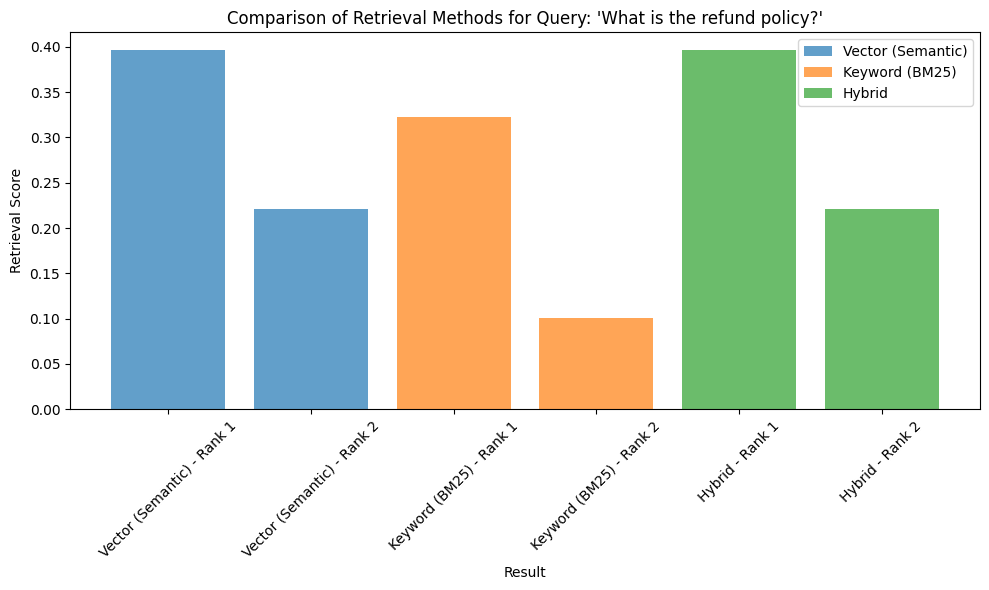

In [30]:
# Example usage:
comparison = compare_retrieval_methods(index, "What is the refund policy?")

In [31]:
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.core.schema import NodeWithScore

# Create a reranker
def rerank_results(nodes, query, top_n=2):
    """Rerank retrieved nodes using the Sentence Transformer reranker."""
    # Create the reranker
    reranker = SentenceTransformerRerank(
        model="cross-encoder/ms-marco-MiniLM-L-6-v2",
        top_n=top_n
    )

    # Rerank the nodes
    reranked_nodes = reranker.postprocess_nodes(
        nodes,
        query_str=query
    )

    return reranked_nodes

# Function to demonstrate the reranking process
def demonstrate_reranking(index, query, top_k=4):
    """Demonstrate the reranking process on retrieval results."""
    # First retrieve more nodes than we need
    retriever = index.as_retriever(similarity_top_k=top_k)
    nodes = retriever.retrieve(query)

    print(f"Query: {query}")
    print("\nOriginal Retrieval Order:")
    for i, node in enumerate(nodes):
        print(f"{i+1}. (Score: {node.score:.4f}) - {node.get_text()[:100]}...")

    # Now rerank them
    reranked_nodes = rerank_results(nodes, query, top_n=2)

    print("\nAfter Reranking:")
    for i, node in enumerate(reranked_nodes):
        print(f"{i+1}. (Score: {node.score:.4f}) - {node.get_text()[:100]}...")

    # Create comparison dataframe
    results = []

    # Original ranking
    for i, node in enumerate(nodes):
        results.append({
            "Stage": "Original Retrieval",
            "Rank": i + 1,
            "Score": node.score,
            "Content": node.get_text()[:150] + "...",
            "Page": node.metadata.get("page_number", "Unknown")
        })

    # Reranked
    for i, node in enumerate(reranked_nodes):
        results.append({
            "Stage": "After Reranking",
            "Rank": i + 1,
            "Score": node.score,
            "Content": node.get_text()[:150] + "...",
            "Page": node.metadata.get("page_number", "Unknown")
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    return results_df

# Example usage:
reranking_demo = demonstrate_reranking(index, "What happens if I cancel the service?", top_k=4)

Query: What happens if I cancel the service?

Original Retrieval Order:
1. (Score: 0.2854) - SERVICE AGREEMENT CONTRACT
This Service Agreement (the "Agreement") is entered into as of January 15...
2. (Score: 0.1487) - 4.3 No refunds will be issued for completed projects that meet the specifications outlined in Exhibi...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]


After Reranking:
1. (Score: -8.6303) - SERVICE AGREEMENT CONTRACT
This Service Agreement (the "Agreement") is entered into as of January 15...
2. (Score: -11.1429) - 4.3 No refunds will be issued for completed projects that meet the specifications outlined in Exhibi...


,Stage,Rank,Score,Content,Page
0,Original Retrieval,1,-8.630345,SERVICE AGREEMENT CONTRACT\nThis Service Agree...,1
1,Original Retrieval,2,-11.142858,4.3 No refunds will be issued for completed pr...,2
2,After Reranking,1,-8.630345,SERVICE AGREEMENT CONTRACT\nThis Service Agree...,1
3,After Reranking,2,-11.142858,4.3 No refunds will be issued for completed pr...,2


In [32]:
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SentenceTransformerRerank
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import BaseRetriever
from llama_index.core.schema import NodeWithScore, QueryBundle

def build_rag_pipeline(index):
    """Build a simple but effective RAG pipeline with hybrid retrieval and reranking."""

    # Get all nodes from the index's docstore
    nodes = list(index.docstore.docs.values())

    # Determine safe top_k value (number of nodes to retrieve)
    # Must be at least 1 and no more than the number of available nodes
    num_nodes = len(nodes)
    safe_top_k = min(2, max(1, num_nodes))

    print(f"Index contains {num_nodes} nodes, using top_k={safe_top_k}")

    # Step 1: Create a hybrid retriever combining vector and keyword search
    # First, get the vector retriever (for semantic understanding)
    vector_retriever = index.as_retriever(
        similarity_top_k=safe_top_k  # Retrieve top 3 most similar chunks
    )

    # Next, create a BM25 retriever (for keyword matching)
    # Get all nodes from the index's docstore
    nodes = list(index.docstore.docs.values())
    bm25_retriever = BM25Retriever.from_defaults(
        nodes=nodes,
        similarity_top_k=safe_top_k  # Retrieve top 3 most similar chunks
    )

    # Create a proper hybrid retriever class
    class HybridRetriever(BaseRetriever):
        """Hybrid retriever that combines vector and keyword search results."""

        def __init__(self, vector_retriever, keyword_retriever, top_k=2):
            """Initialize with vector and keyword retrievers."""
            self.vector_retriever = vector_retriever
            self.keyword_retriever = keyword_retriever
            self.top_k = top_k
            super().__init__()

        def _retrieve(self, query_bundle, **kwargs):
            """Retrieve from both retrievers and combine results."""
            # Get results from both retrievers
            vector_nodes = self.vector_retriever.retrieve(query_bundle)
            keyword_nodes = self.keyword_retriever.retrieve(query_bundle)

            # Combine all nodes
            all_nodes = list(vector_nodes) + list(keyword_nodes)

            # Remove duplicates (by node_id)
            unique_nodes = {}
            for node in all_nodes:
                if node.node_id not in unique_nodes:
                    unique_nodes[node.node_id] = node

            # Sort by score (higher is better)
            sorted_nodes = sorted(
                unique_nodes.values(),
                key=lambda x: x.score if hasattr(x, 'score') else 0.0,
                reverse=True
            )

            return sorted_nodes[:self.top_k]  # Return top results

    # Create our hybrid retriever instance
    hybrid_retriever = HybridRetriever(
        vector_retriever=vector_retriever,
        keyword_retriever=bm25_retriever,
        top_k=safe_top_k
    )

    # Step 2: Create a reranker to prioritize the most relevant chunks
    if num_nodes > 1:
        reranker = SentenceTransformerRerank(
            model="cross-encoder/ms-marco-MiniLM-L-6-v2",
            top_n=min(2, num_nodes)  # Keep only top results after reranking
        )
        node_postprocessors = [reranker]
    else:
        node_postprocessors = []


    # Step 3: Build the query engine
    query_engine = RetrieverQueryEngine.from_args(
        retriever=hybrid_retriever,
        llm=llm,
        node_postprocessors=[reranker]
    )

    return query_engine

In [34]:
# Example usage:
#pdf_path = upload_pdf()
index = process_and_index_pdf(pdf_path)
rag_engine = build_rag_pipeline(index)
response = rag_engine.query("What are the penalties for late payments?")
print('\nFinal Response:\n ---------------------- \n')
print(response)

Processed /content/sample_docs/sample_contract.pdf:
Extracted 2 pages with content


DEBUG:bm25s:Building index from IDs objects


Indexed 2 document chunks
Index contains 2 nodes, using top_k=2


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Final Response:
 ---------------------- 

Late payments will be charged interest at a rate of 1.5% per month from the due date until the balance is paid in full.

